Weights: [0.9        1.37150988 0.04589862]


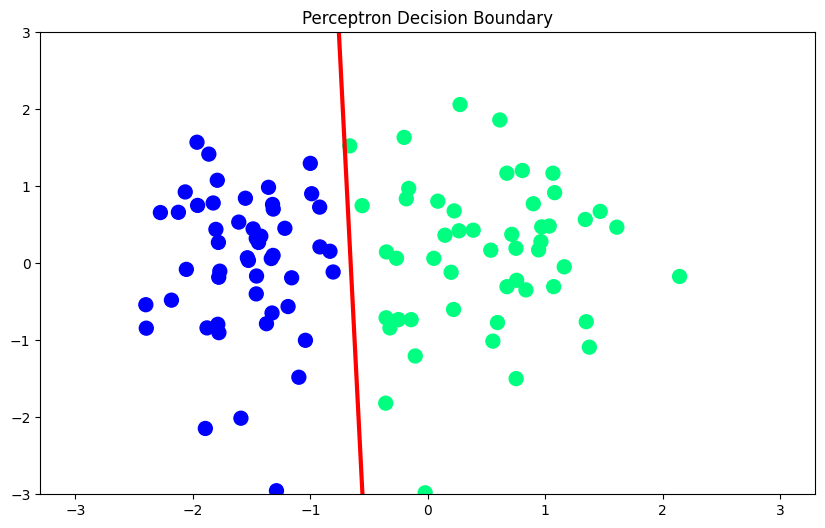

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# Step function
def step(z):
    return 1 if z > 0 else 0

# Perceptron
def perceptron(X, y):
    X = np.insert(X, 0, 1, axis=1)  # add bias term
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(200):
        j = np.random.randint(0, X.shape[0])
        y_hat = step(np.dot(X[j], weights))
        weights = weights + lr * (y[j] - y_hat) * X[j]

    return weights  # ✅ return final weights


# Create dataset
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_informative=1,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=41,
    hypercube=False,
    class_sep=10
)

# Train model
weights = perceptron(X, y)

print("Weights:", weights)

# Decision boundary
m = -(weights[1] / weights[2])
b = -(weights[0] / weights[2])

# Plot
plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)

x_input = np.linspace(-3, 3, 200)
y_input = m * x_input + b

plt.plot(x_input, y_input, color='red', linewidth=3)
plt.ylim(-3, 3)

plt.title("Perceptron Decision Boundary")
plt.show()

Weights: [1.37576054 2.77418227 0.11765518]


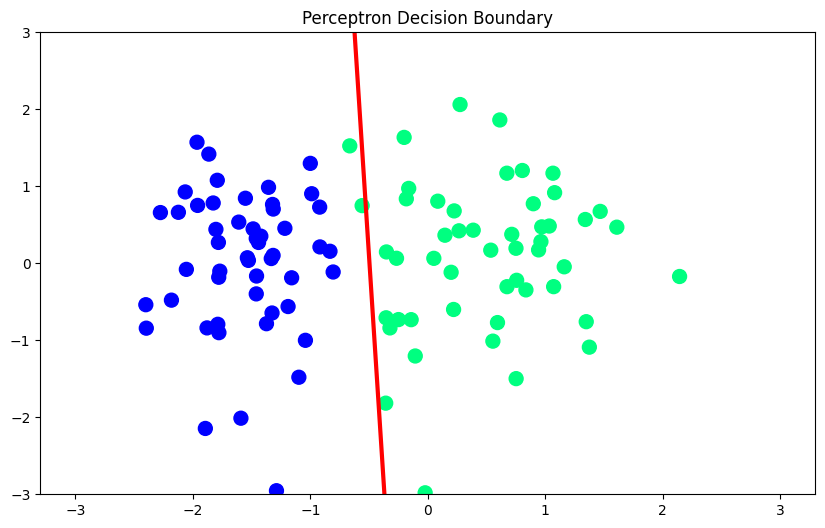

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# Step function
def sigmoid(z):
    return 1/(1+np.exp(-z))

# Perceptron
def perceptron(X, y):
    X = np.insert(X, 0, 1, axis=1)  # add bias term
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(200):
        j = np.random.randint(0, X.shape[0])
        y_hat = sigmoid(np.dot(X[j], weights))
        weights = weights + lr * (y[j] - y_hat) * X[j]

    return weights  # ✅ return final weights


# Create dataset
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_informative=1,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=41,
    hypercube=False,
    class_sep=10
)

# Train model
weights = perceptron(X, y)

print("Weights:", weights)

# Decision boundary
m = -(weights[1] / weights[2])
b = -(weights[0] / weights[2])

# Plot
plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)

x_input = np.linspace(-3, 3, 200)
y_input = m * x_input + b

plt.plot(x_input, y_input, color='red', linewidth=3)
plt.ylim(-3, 3)

plt.title("Perceptron Decision Boundary")
plt.show()

Weights: [0.9        1.30392481 0.12768526]


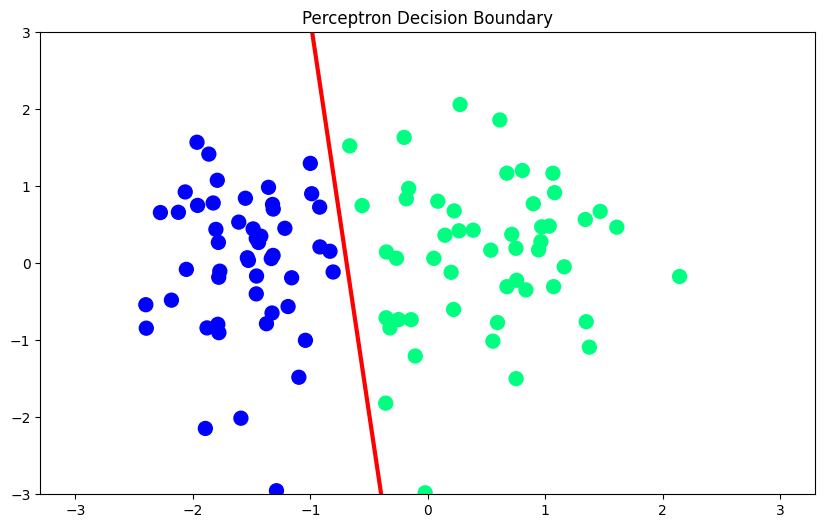

In [ ]:
# using gradient Decsent
def gd(X,y):
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.5
    
    for i in range(5000):
        y_hat = sigmoid(np.dot(X,weights))
        weights = weights + lr*(np.dot((y-y_hat),X)/X.shape[0])
        
    return weights[1:],weights[0]

# Create dataset
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_informative=1,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=41,
    hypercube=False,
    class_sep=10
)

# Train model
weights = perceptron(X, y)

print("Weights:", weights)

# Decision boundary
m = -(weights[1] / weights[2])
b = -(weights[0] / weights[2])

# Plot
plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)

x_input = np.linspace(-3, 3, 200)
y_input = m * x_input + b

plt.plot(x_input, y_input, color='red', linewidth=3)
plt.ylim(-3, 3)

plt.title("Perceptron Decision Boundary")
plt.show()

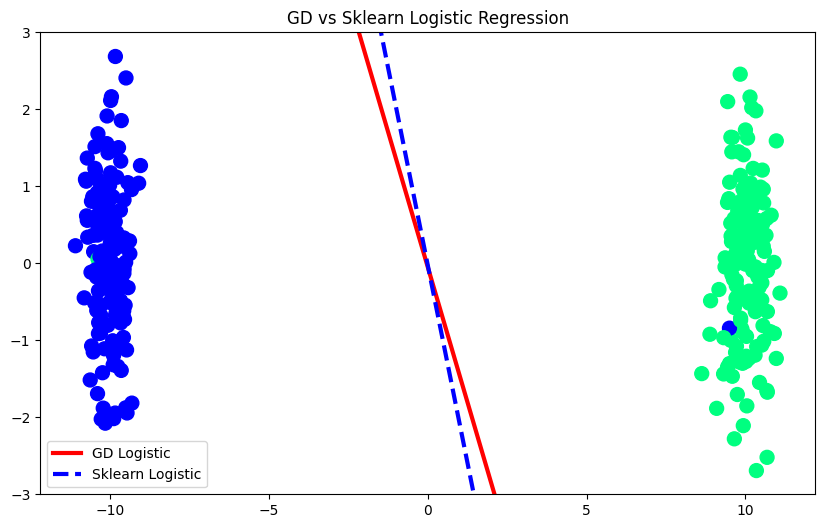

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

# =========================
# Sigmoid Function
# =========================
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# =========================
# Gradient Descent Logistic Regression
# =========================
def gd(X, y):
    X = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.5

    for i in range(5000):
        y_hat = sigmoid(np.dot(X, weights))
        weights = weights + lr * (np.dot((y - y_hat), X) / X.shape[0])

    return weights


# =========================
# Dataset
# =========================
X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_informative=1,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=41,
    class_sep=10
)

# =========================
# Train GD Logistic
# =========================
weights_gd = gd(X, y)

w0_gd, w1_gd, w2_gd = weights_gd

# Decision boundary (GD)
x_input = np.linspace(-3, 3, 200)
y_gd = -(w0_gd + w1_gd * x_input) / w2_gd


# =========================
# Train Sklearn Logistic
# =========================
lr = LogisticRegression()
lr.fit(X, y)

w0_lr = lr.intercept_[0]
w1_lr = lr.coef_[0][0]
w2_lr = lr.coef_[0][1]

y_lr = -(w0_lr + w1_lr * x_input) / w2_lr


# =========================
# Plot Comparison
# =========================
plt.figure(figsize=(10,6))

# Data points
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)

# GD line
plt.plot(x_input, y_gd, color='red', linewidth=3, label='GD Logistic')

# Sklearn line
plt.plot(x_input, y_lr, color='blue', linewidth=3, linestyle='--', label='Sklearn Logistic')

plt.ylim(-3, 3)
plt.legend()
plt.title("GD vs Sklearn Logistic Regression")
plt.show()

AUC: 0.9977071732721913
Best Threshold: 0.8508956997097988

--- Default Threshold (0.5) ---
Accuracy: 0.956140350877193
Confusion Matrix:
 [[39  4]
 [ 1 70]]

--- Optimized Threshold ---
Accuracy: 0.9824561403508771
Confusion Matrix:
 [[43  0]
 [ 2 69]]


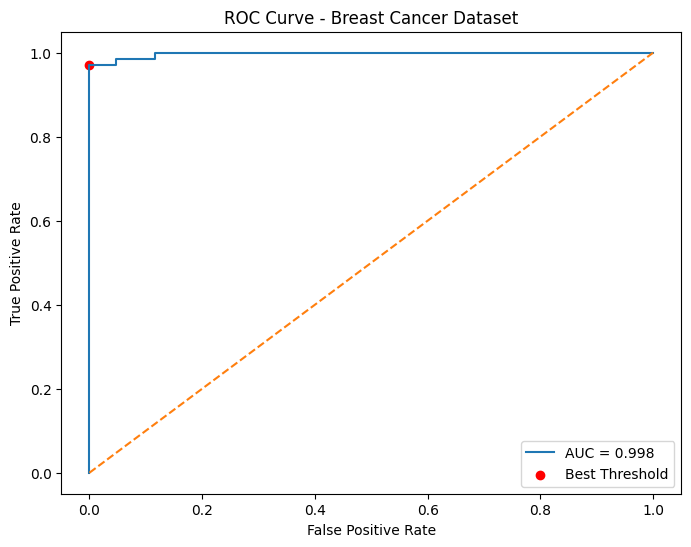

In [22]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

# =========================
# Load Dataset
# =========================
data = load_breast_cancer()
X = data.data
y = data.target   # 0 = malignant, 1 = benign

# =========================
# Train/Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# Train Model
# =========================
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# =========================
# Get Probabilities
# =========================
y_prob = model.predict_proba(X_test)[:,1]

# =========================
# ROC Curve
# =========================
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)

# =========================
# Best Threshold
# =========================
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print("Best Threshold:", optimal_threshold)

# =========================
# Predictions
# =========================

# Default threshold (0.5)
y_pred_default = (y_prob >= 0.5).astype(int)

# Optimized threshold
y_pred_optimal = (y_prob >= optimal_threshold).astype(int)

# =========================
# Evaluation
# =========================
print("\n--- Default Threshold (0.5) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_default))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_default))

print("\n--- Optimized Threshold ---")
print("Accuracy:", accuracy_score(y_test, y_pred_optimal))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_optimal))

# =========================
# Plot ROC Curve
# =========================
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label="AUC = " + str(round(roc_auc, 3)))
plt.plot([0,1],[0,1],'--')

# Mark best threshold
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', label='Best Threshold')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Breast Cancer Dataset")
plt.legend()
plt.show()